In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

plt.rcParams['figure.figsize'] = (12, 12)
plt.rcParams['font.size'] = 11
np.random.seed(42)

In [2]:
def generate_gue(N):
    """Генерирует случайную матрицу из Гауссовского унитарного ансамбля (GUE)"""
    X = (np.random.randn(N, N) + 1j * np.random.randn(N, N))
    H = (X + X.conj().T) / 2
    return H

In [3]:
def semicircle_law(x, R=2):
    """Плотность полукругового закона Вигнера"""
    y = np.zeros_like(x)
    mask = np.abs(x) <= R
    y[mask] = (2 / (np.pi * R**2)) * np.sqrt(R**2 - x[mask]**2)
    return y

In [4]:
def plot_wigner_comparison(N, ax, bins=40):
    """Строит гистограмму собственных значений и полукруговой закон для заданного N"""
    
    H = generate_gue(N)
    eigenvalues = np.real(eigh(H, eigvals_only=True))
    eigenvalues_normalized = eigenvalues / np.sqrt(N)
    
    # гистограмма
    ax.hist(eigenvalues_normalized, bins=bins, density=True, 
            alpha=0.7, color='lightgreen', edgecolor='green', 
            label='Нормированная гистограмма собственных значений', zorder=1)
    
    # теоретическая кривая
    x = np.linspace(-2.5, 2.5, 400)
    y = semicircle_law(x)
    ax.plot(x, y, 'g-', linewidth=2.5, label='Полукруговой закон', zorder=2)
    
    ax.set_xlabel('Собственное значение')
    ax.set_ylabel('Плотность')
    ax.set_title(f'Матрица GUE, размер N = {N}')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0, 0.5)

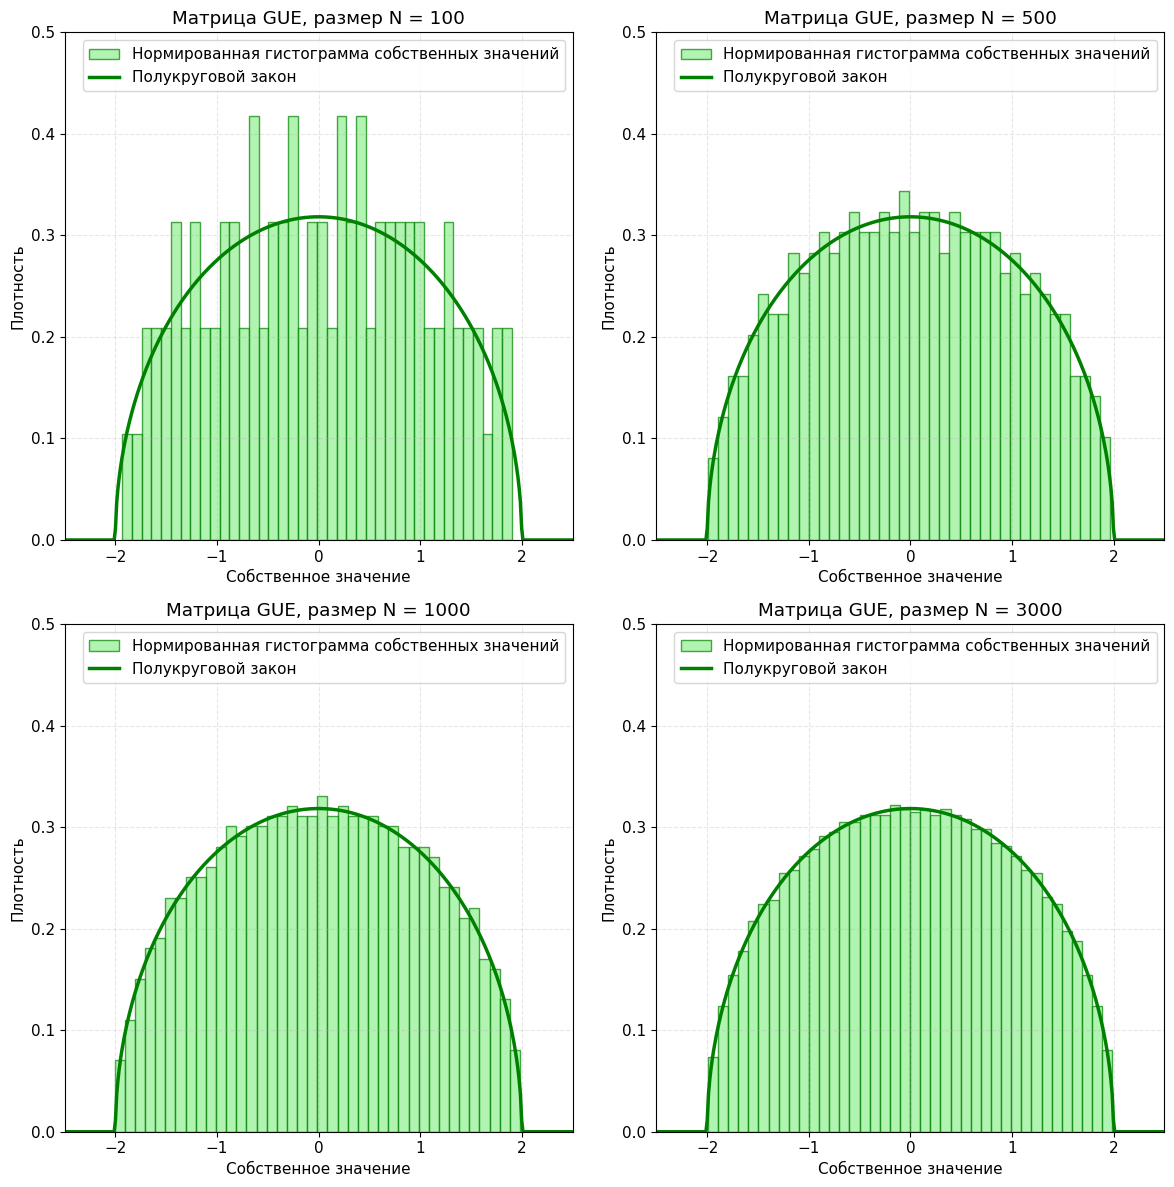

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

Ns = [100, 500, 1000, 3000]

for N, ax in zip(Ns, axes.flatten()):
    plot_wigner_comparison(N, ax)

plt.tight_layout()
#plt.savefig('./pictures for diplom/test.png')
plt.show()